# Masks from the gradient energy

Loads the 16 test images of this folder, computes the cubic-spline gradient
(the default gradient of OrientationJ), and builds a binary mask where the gradient
energy $g_x^2 + g_y^2$ exceeds 1% of its maximum over the image. The masks are saved
in the folder `masks/` as 8-bit TIFF (0 / 255), one per image, under the same file name.

In [19]:
import os

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import spline_filter1d
from skimage.io import imsave

import synthetic_images_2D as sim

THRESHOLD = 0.005

plt.rcParams.update({
    'figure.facecolor': 'white', 'font.size': 10, 'axes.titlesize': 7,
    'axes.edgecolor': '#cfcec6', 'grid.color': '#e8e8e4', 'grid.linewidth': 0.8,
})

files = sorted(name for name in os.listdir(os.path.join('..', 'images')) if name.endswith('.tif'))
print(len(files), 'images')

16 images


In [20]:
os.makedirs(os.path.join('..', 'masks'), exist_ok=True)

images = {}
masks = {}
for file in files:
    name = file[:-len('.tif')]
    image = sim.load(os.path.join('..', 'images', file))
    # cubic-spline gradient, as orientation_simulation.gradient (mode 'spline')
    gx = np.gradient(spline_filter1d(image, order=3, axis=1, mode='mirror'), axis=1)
    gy = np.gradient(spline_filter1d(image, order=3, axis=0, mode='mirror'), axis=0)
    energy = gx ** 2 + gy ** 2
    images[name] = image
    masks[name] = energy > THRESHOLD * energy.max()
    path = os.path.join('..', 'masks', file)
    imsave(path, (masks[name] * 255).astype(np.uint8), check_contrast=False)
    print('saved', path, ' coverage', round(100 * masks[name].mean(), 1), '%')

saved masks/artificial_fibers.tif  coverage 54.8 %
saved masks/cell_aemisegger.tif  coverage 25.8 %
saved masks/collagen.tif  coverage 40.2 %
saved masks/dendrochronology.tif  coverage 46.4 %
saved masks/fibronectin_arafat_plos2025.tif  coverage 51.2 %
saved masks/fibrous_tissues_fibero2024.tif  coverage 5.3 %
saved masks/fiji_directionality_test_image.tif  coverage 80.1 %
saved masks/nanofiber_fiji_diameterj.tif  coverage 39.5 %
saved masks/polymer_slice_quanfima2018.tif  coverage 14.5 %
saved masks/synthetic_chirp_512.tif  coverage 61.5 %
saved masks/synthetic_filaments_512.tif  coverage 47.8 %
saved masks/synthetic_nematic_512.tif  coverage 73.5 %
saved masks/synthetic_noise_512.tif  coverage 82.7 %
saved masks/synthetic_rings_512.tif  coverage 21.0 %
saved masks/synthetic_spiral_512.tif  coverage 80.2 %
saved masks/synthetic_wave_512.tif  coverage 94.9 %


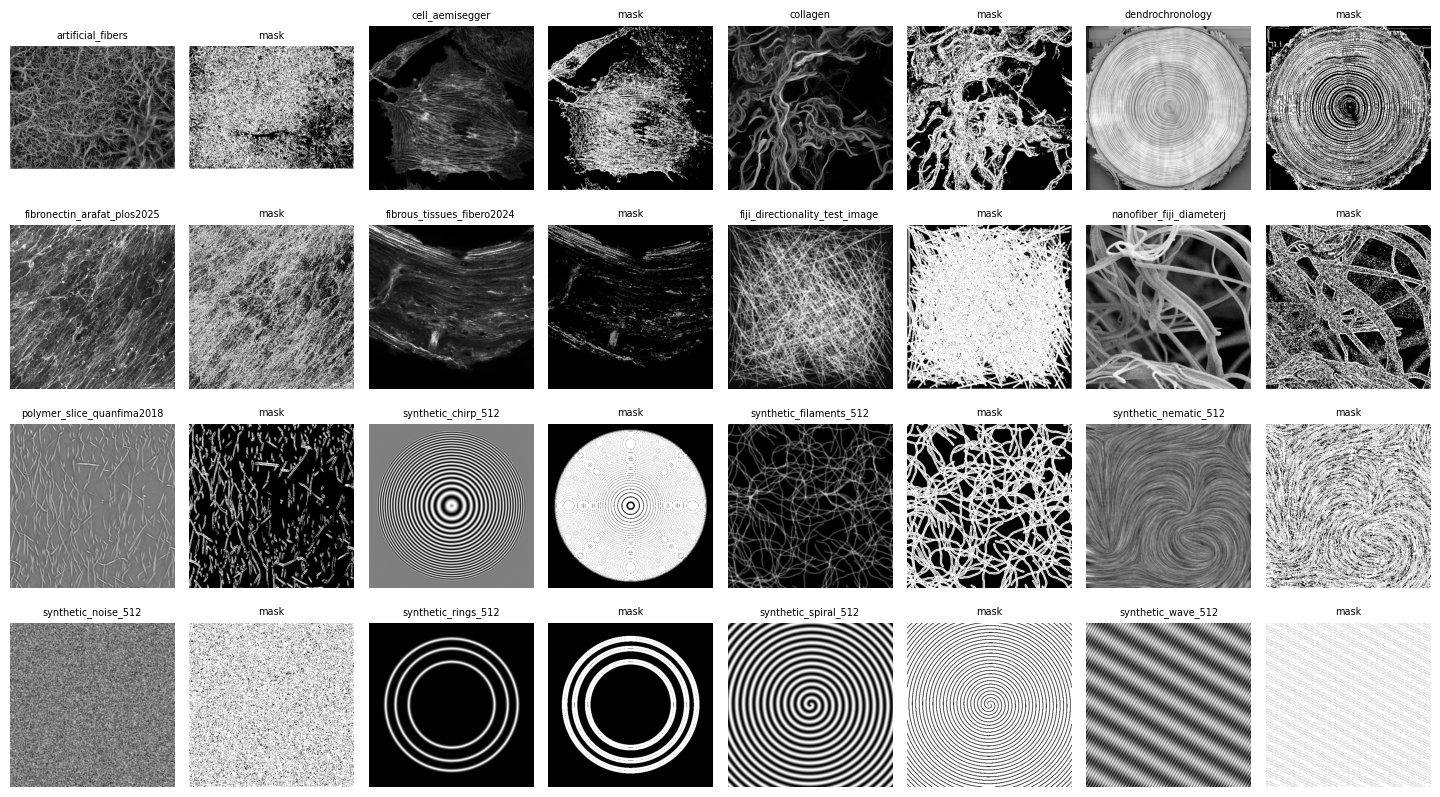

In [21]:
names = list(images.keys())
fig, axes = plt.subplots(4, 8, figsize=(14.5, 8.2))
for ax in axes.ravel():
    ax.axis('off')
for index in range(len(names)):
    row = index // 4
    column = 2 * (index % 4)
    axes[row][column].imshow(images[names[index]], cmap='gray')
    axes[row][column].set_title(names[index])
    axes[row][column + 1].imshow(masks[names[index]], cmap='gray', vmin=0, vmax=1)
    axes[row][column + 1].set_title('mask')
fig.tight_layout()
plt.show()